In [1]:
!pip install snntorch

In [33]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import itertools

In [34]:
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [35]:
## DATA PREP
# Define a transform
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)
# Create DataLoaders
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

In [36]:
# Network Architecture
num_inputs = 28*28
num_hidden = 100 # but 5 layers
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.75

In [22]:
# DEFINE NETWORK
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_hidden)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc3 = nn.Linear(num_hidden, num_hidden)
        self.lif3 = snn.Leaky(beta=beta)
        self.fc4 = nn.Linear(num_hidden, num_hidden)
        self.lif4 = snn.Leaky(beta=beta)
        self.fc5 = nn.Linear(num_hidden, num_hidden)
        self.lif5 = snn.Leaky(beta=beta)
        self.fc6 = nn.Linear(num_hidden, num_outputs)
        self.lif6 = snn.Leaky(beta=beta)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem5 = self.lif5.init_leaky()
        mem6 = self.lif6.init_leaky()
        
        # Record the final layer
        spk6_rec = []
        mem6_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc3(spk1)
            spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.fc4(spk1)
            spk4, mem4 = self.lif4(cur4, mem4)
            cur5 = self.fc5(spk1)
            spk5, mem5 = self.lif5(cur5, mem5)
            cur6 = self.fc6(spk1)
            spk6, mem6 = self.lif6(cur6, mem6)
            spk6_rec.append(spk6)
            mem6_rec.append(mem6)

        return torch.stack(spk6_rec, dim=0), torch.stack(mem6_rec, dim=0)
        
# Load the network onto CUDA if available
net = Net().to(device)

In [37]:
# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target

def print_batch_accuracy(data, targets, train=False):
    output, _ = net(data.view(batch_size, -1))
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

In [24]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

In [25]:
num_epochs = 2
loss_hist = []
test_loss_hist = []
counter = 0

# Outer training loop
for epoch in range(num_epochs):
    iter_counter = 0
    train_batch = iter(train_loader)

    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)

        # forward pass
        net.train()
        spk_rec, mem_rec = net(data.view(batch_size, -1))

        # initialize the loss & sum over time
        loss_val = torch.zeros((1), dtype=dtype, device=device)
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())

        # Test set
        with torch.no_grad():
            net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)

            # Test set forward pass
            test_spk, test_mem = net(test_data.view(batch_size, -1))

            # Test set loss
            test_loss = torch.zeros((1), dtype=dtype, device=device)
            for step in range(num_steps):
                test_loss += loss(test_mem[step], test_targets)
            test_loss_hist.append(test_loss.item())

            # Print train/test loss/accuracy
            if counter % 50 == 0:
                train_printer(
                    data, targets, epoch,
                    counter, iter_counter,
                    loss_hist, test_loss_hist,
                    test_data, test_targets)
            counter += 1
            iter_counter +=1

Epoch 0, Iteration 0
Train Set Loss: 59.40
Test Set Loss: 57.95
Train set accuracy for a single minibatch: 9.38%
Test set accuracy for a single minibatch: 13.28%


Epoch 0, Iteration 50
Train Set Loss: 27.49
Test Set Loss: 27.10
Train set accuracy for a single minibatch: 78.91%
Test set accuracy for a single minibatch: 79.69%


Epoch 0, Iteration 100
Train Set Loss: 14.86
Test Set Loss: 15.64
Train set accuracy for a single minibatch: 90.62%
Test set accuracy for a single minibatch: 86.72%


Epoch 0, Iteration 150
Train Set Loss: 11.83
Test Set Loss: 11.25
Train set accuracy for a single minibatch: 85.16%
Test set accuracy for a single minibatch: 91.41%


Epoch 0, Iteration 200
Train Set Loss: 8.58
Test Set Loss: 8.94
Train set accuracy for a single minibatch: 92.19%
Test set accuracy for a single minibatch: 91.41%


Epoch 0, Iteration 250
Train Set Loss: 9.01
Test Set Loss: 7.77
Train set accuracy for a single minibatch: 91.41%
Test set accuracy for a single minibatch: 92.19%


Epoch 

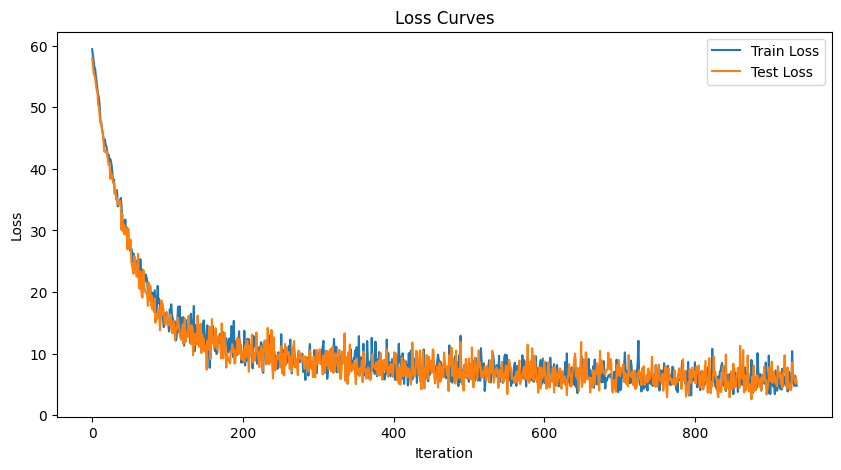

In [26]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss Curves")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [27]:
total = 0
correct = 0

# drop_last switched to False to keep all samples
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

with torch.no_grad():
  net.eval()
  for data, targets in test_loader:
    data = data.to(device)
    targets = targets.to(device)
    
    # forward pass
    test_spk, _ = net(data.view(data.size(0), -1))

    # calculate total accuracy
    _, predicted = test_spk.sum(dim=0).max(1)
    total += targets.size(0)
    correct += (predicted == targets).sum().item()

print(f"Total correctly classified test set images: {correct}/{total}")
print(f"Test Set Accuracy: {100 * correct / total:.2f}%")

Total correctly classified test set images: 9217/10000
Test Set Accuracy: 92.17%


In [ ]:
class Dynamic_Net(nn.Module):
    def __init__(self, layer_num, beta, step_num, hidden_num, stdp_lr=0.01, weight_decay=0.99, trace_decay=0.99):
        super().__init__()
        self.layer_num = layer_num
        self.beta = beta
        self.step_num = step_num
        self.hidden_num = hidden_num
        self.stdp_lr = stdp_lr
        self.weight_decay = weight_decay
        self.trace_decay = trace_decay
        
        # initialize input, inner, and output layer
        self.inputFC = nn.Linear(num_inputs, self.hidden_num)
        self.inputLIF = snn.Leaky(beta=self.beta)
        self.innerLayer = nn.ModuleList()
        self.innerLIF = nn.ModuleList()
        for ln in range(layer_num):
          self.innerLayer.append(nn.Linear(self.hidden_num, self.hidden_num))
          self.innerLIF.append(snn.Leaky(beta=self.beta))
        self.outputFC = nn.Linear(self.hidden_num, num_outputs)
        self.outputLIF = snn.Leaky(beta=self.beta)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem_in = self.inputLIF.init_leaky()
        mem_hidden = []
        for layer in self.innerLIF:
          mem_hidden.append(layer.init_leaky())
        mem_out = self.outputLIF.init_leaky()
          
        
        # Record the final layer
        spk_rec = []
        mem_rec = []

        for step in range(self.step_num):
            cur = self.inputFC(x)
            spk, mem_in = self.inputLIF(cur, mem_in)
            for idx in range(self.layer_num):
              cur = self.innerLayer[idx](spk)
              spk, mem_hidden[idx] = self.innerLIF[idx](cur, mem_hidden[idx])
              
            cur = self.outputFC(spk)
            spk, mem_out = self.outputLIF(cur, mem_out)
            spk_rec.append(spk)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)
        
# Load the network onto CUDA if available


betas = [0.75, 0.85, 0.95, 0.99]
layer_nums = [2, 3, 4, 5]
neuron_nums = [100, 200]
step_nums = [25, 50, 100]
# betas = [0.95]
# layer_nums = [4]
# neuron_nums = [100]
# step_nums = [25]
accuracy_rec = []
for b in betas:
  for sn in step_nums:
    for ln in layer_nums:
      for n in neuron_nums:
        net = Dynamic_Net(layer_num=ln, beta=b, step_num=sn, hidden_num=n).to(device)

        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))
        
        num_epochs = 1
        loss_hist = []
        test_loss_hist = []
        counter = 0

        # Outer training loop
        for epoch in range(num_epochs):
            iter_counter = 0
            train_batch = iter(train_loader)

            # Minibatch training loop
            for data, targets in train_batch:
                data = data.to(device)
                targets = targets.to(device)

                # forward pass
                net.train()
                spk_rec, mem_rec = net(data.view(batch_size, -1))

                # initialize the loss & sum over time
                loss_val = torch.zeros((1), dtype=dtype, device=device)
                for step in range(sn):
                    loss_val += loss(mem_rec[step], targets)

                # Gradient calculation + weight update
                optimizer.zero_grad()
                loss_val.backward()
                optimizer.step()

                # Store loss history for future plotting
                loss_hist.append(loss_val.item())

                # Test set
                with torch.no_grad():
                    net.eval()
                    test_data, test_targets = next(iter(test_loader))
                    test_data = test_data.to(device)
                    test_targets = test_targets.to(device)

                    # Test set forward pass
                    test_spk, test_mem = net(test_data.view(batch_size, -1))

                    # Test set loss
                    test_loss = torch.zeros((1), dtype=dtype, device=device)
                    for step in range(sn):
                        test_loss += loss(test_mem[step], test_targets)
                    test_loss_hist.append(test_loss.item())

                    # Print train/test loss/accuracy
                    if counter % 50 == 0:
                        train_printer(
                            data, targets, epoch,
                            counter, iter_counter,
                            loss_hist, test_loss_hist,
                            test_data, test_targets)
                    counter += 1
                    iter_counter +=1
        
        total = 0
        correct = 0

        # drop_last switched to False to keep all samples
        test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

        with torch.no_grad():
          net.eval()
          for data, targets in test_loader:
            data = data.to(device)
            targets = targets.to(device)
            
            # forward pass
            test_spk, _ = net(data.view(data.size(0), -1))

            # calculate total accuracy
            _, predicted = test_spk.sum(dim=0).max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

        print(f"Total correctly classified test set images: {correct}/{total}")
        print(f"Test Set Accuracy: {100 * correct / total:.2f}%")
        accuracy_rec.append(100 * correct / total)
        
        
print(accuracy_rec)

Epoch 0, Iteration 0
Train Set Loss: 58.69
Test Set Loss: 57.88
Train set accuracy for a single minibatch: 14.84%
Test set accuracy for a single minibatch: 8.59%


Epoch 0, Iteration 50
Train Set Loss: 41.95
Test Set Loss: 41.16
Train set accuracy for a single minibatch: 40.62%
Test set accuracy for a single minibatch: 38.28%


Epoch 0, Iteration 100
Train Set Loss: 17.18
Test Set Loss: 15.85
Train set accuracy for a single minibatch: 83.59%
Test set accuracy for a single minibatch: 87.50%


Epoch 0, Iteration 150
Train Set Loss: 9.71
Test Set Loss: 14.91
Train set accuracy for a single minibatch: 89.06%
Test set accuracy for a single minibatch: 85.16%


Epoch 0, Iteration 200
Train Set Loss: 8.09
Test Set Loss: 6.26
Train set accuracy for a single minibatch: 92.97%
Test set accuracy for a single minibatch: 93.75%


Epoch 0, Iteration 250
Train Set Loss: 10.26
Test Set Loss: 6.34
Train set accuracy for a single minibatch: 90.62%
Test set accuracy for a single minibatch: 91.41%


Epoch 

In [46]:
print(len(accuracy_rec))

96


In [49]:
heatmap_data = np.array(accuracy_rec).reshape(12,8).transpose()
print(heatmap_data)

[[94.   93.81 93.15 94.16 93.68 93.69 91.09 94.53 94.51 92.67 93.65 94.67]
 [91.65 91.72 93.86 92.31 94.09 90.4  93.05 93.01 92.77 94.58 89.64 92.35]
 [93.11 93.74 93.11 91.49 94.13 93.97 93.17 94.6  94.43 92.2  94.86 93.55]
 [92.   93.5  93.35 93.86 91.31 91.98 91.88 94.06 92.24 92.95 95.6  94.83]
 [92.36 92.5  92.36 93.21 93.16 93.14 94.07 93.61 92.15 92.21 91.04 92.28]
 [93.07 93.1  92.58 93.18 93.8  94.43 93.01 92.15 89.7  94.3  94.08 91.39]
 [91.26 90.61 92.75 91.6  91.75 93.34 93.6  93.87 93.29 94.69 94.06 94.12]
 [93.02 94.11 93.64 94.61 94.72 94.11 93.99 93.16 93.9  93.4  94.27 95.26]]


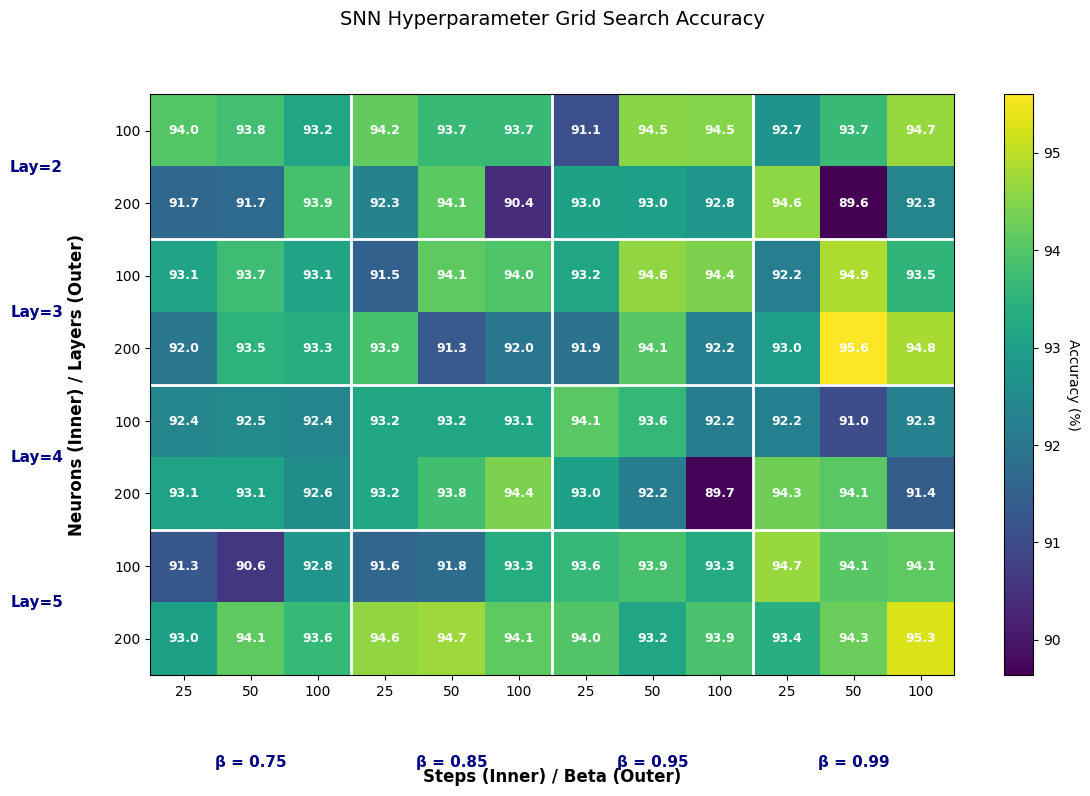

In [56]:
data_4d = np.array(accuracy_rec).reshape(len(betas), len(step_nums), len(layer_nums), len(neuron_nums))

# Step B: Permute dimensions to put Y-axis attributes first, then X-axis attributes.
# We want: (Layer, Neuron) on vertical, (Beta, Step) on horizontal.
# Current indices: 0:Beta, 1:Step, 2:Layer, 3:Neuron
# Desired indices: 2:Layer, 3:Neuron, 0:Beta, 1:Step
data_permuted = data_4d.transpose(2, 3, 0, 1)

data_matrix = data_permuted.reshape(8, 12)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap
im = ax.imshow(data_matrix, cmap='viridis', aspect='auto')

# Add Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Accuracy (%)", rotation=-90, va="bottom")

# 4. ADD TEXT ANNOTATIONS (The values inside the squares)
for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        text = ax.text(j, i, f"{data_matrix[i, j]:.1f}",
                       ha="center", va="center", color="w", fontsize=9, fontweight='bold')

# 5. CONFIGURE X-AXIS (Beta / Step)
# Inner Labels (Steps)
ax.set_xticks(np.arange(12))
ax.set_xticklabels(step_nums * 4)
ax.set_xlabel("Steps (Inner) / Beta (Outer)", labelpad=50, fontweight='bold', fontsize=12)

# Outer Labels (Betas) - Manually placed
for i, b in enumerate(betas):
    # Calculate center position for the group of 3 columns
    center_x = (i * 3) + 1 
    # Place text slightly below the X-axis (y = 8.2 in axis coordinates)
    ax.text(center_x, 8.6, f"β = {b}", ha='center', va='top', fontsize=11, fontweight='bold', color='navy')
    
    # Draw vertical separator lines
    if i > 0:
        ax.axvline(x=(i * 3) - 0.5, color='white', linewidth=2)

# 6. CONFIGURE Y-AXIS (Layer / Neuron)
# Inner Labels (Neurons)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(neuron_nums * 4)
ax.set_ylabel("Neurons (Inner) / Layers (Outer)", labelpad=20, fontweight='bold', fontsize=12)

# Outer Labels (Layers) - Manually placed
for i, l in enumerate(layer_nums):
    # Calculate center position for the group of 2 rows
    center_y = (i * 2) + 0.5
    # Place text slightly to the left of Y-axis (x = -1.2)
    ax.text(-1.8, center_y, f"Lay={l}", ha='right', va='center', fontsize=11, fontweight='bold', color='navy')
    
    # Draw horizontal separator lines
    if i > 0:
        ax.axhline(y=(i * 2) - 0.5, color='white', linewidth=2)

# Adjust layout to make room for the outer labels
plt.title("SNN Hyperparameter Grid Search Accuracy", pad=50, fontsize=14)
plt.tight_layout()
plt.subplots_adjust(left=0.15, bottom=0.15) # Add extra margin for outer labels

plt.show()